Instrument Classification and Robustness Analysis Topic Research

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import librosa
import numpy as np  

In [3]:
#Data Path
data_home = "./mirdata/IRMAS-TrainingData"
y_audio_path = "./mirdata/IRMAS-TrainingData/cel/[cel][cla]0001__1.wav"

#load and test data
y, sr = librosa.load(y_audio_path,sr=44100)
#Audio sample in 44.1khz
print(y.shape, sr)



c:\Users\leo89\anaconda3\envs\mir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(132299,) 44100


C:\Users\leo89\AppData\Local\Temp\ipykernel_25660\3082606560.py:5: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)


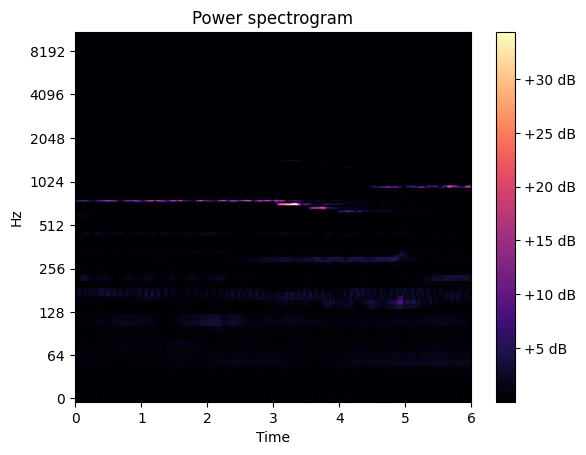

In [3]:
import matplotlib.pyplot as plt 
#audio spectrogram
Y = librosa.stft(y)
fig, ax = plt.subplots()
img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")




In [16]:
from dataset_preprocessing import create_dataset_csv
class_label = {'cel':0, 'pia':1, 'sax':2, 'flu':3, 'vio':4}

#load all data
df = create_dataset_csv(data_home)
#filter data by class label, only 5 classes are used in this project
df_filtered = df[df['label'].isin(class_label.keys())].copy()
df_filtered['label_id'] = df_filtered['label'].map(class_label)

print(df_filtered['label'].value_counts())

label
pia    721
sax    626
vio    580
flu    451
cel    388
Name: count, dtype: int64


In [5]:
import pandas as pd

save_path = "./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv"
df_filtered.to_csv(save_path, index=False, encoding='utf-8')

print("Filtered dataset saved to:", save_path)

Filtered dataset saved to: ./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv


Load CSV, starting from here.

In [4]:
import pandas as pd

save_path = "./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv"
#read the saved csv file to verify
df_dataset = pd.read_csv(save_path)
print(df_dataset.head())


                                           file_path label  label_id
0  ./mirdata/IRMAS-TrainingData\cel\008__[cel][no...   cel         0
1  ./mirdata/IRMAS-TrainingData\cel\008__[cel][no...   cel         0
2  ./mirdata/IRMAS-TrainingData\cel\008__[cel][no...   cel         0
3  ./mirdata/IRMAS-TrainingData\cel\012__[cel][no...   cel         0
4  ./mirdata/IRMAS-TrainingData\cel\012__[cel][no...   cel         0


In [5]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
train_df, test_df = train_test_split(df_dataset, test_size=0.2)
print("Training set size:", len(train_df))
print("Testing set size:", len(test_df))
print("Train set",train_df.head())

Training set size: 2212
Testing set size: 554
Train set                                               file_path label  label_id
433   ./mirdata/IRMAS-TrainingData\flu\150__[flu][dr...   flu         3
2168  ./mirdata/IRMAS-TrainingData\sax\[sax][pop_roc...   sax         2
1955  ./mirdata/IRMAS-TrainingData\sax\[sax][jaz_blu...   sax         2
1743  ./mirdata/IRMAS-TrainingData\sax\[sax][cla]159...   sax         2
142   ./mirdata/IRMAS-TrainingData\cel\[cel][cla]001...   cel         0


In [6]:
y_train = train_df['label_id'].values
y_test = test_df['label_id'].values
train_set = train_df['file_path'].values
test_set = test_df['file_path'].values

#spilt to a smaller training set, set 200
#y_train = y_train[:200]
#train_set = train_set[:200]

#check whether the size match 
assert len(y_train) == len(train_set), "Trainset not aligned"
assert len(y_test) == len(test_set), "Testset not aligned"

In [21]:
from dataset_preprocessing import convert_audio_to_mel_spectrogram

#convert audio to spectrogram for training
x_train = np.array(convert_audio_to_mel_spectrogram(train_set))
x_test = np.array(convert_audio_to_mel_spectrogram(test_set))
print(x_train.shape)
print(x_test.shape)


(2212, 128, 259)
(554, 128, 259)


In [20]:
print(class_label.keys())

dict_keys(['cel', 'pia', 'sax', 'flu', 'vio'])


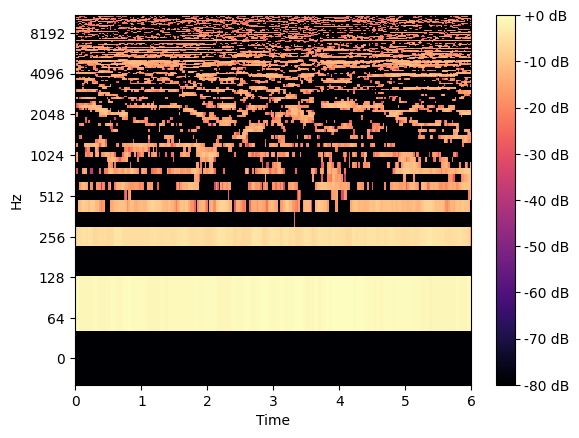

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
img = librosa.display.specshow(x_train[0],y_axis='log', x_axis='time', ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB")

SVM Data preprocessing below!

In [ ]:
#reshape for svm, not for cnn
x_train_reshape = x_train.reshape((x_train.shape[0], 128*259))
x_test_reshape = x_test.reshape((x_test.shape[0], 128*259))

In [9]:
from run_svm import train_svm
#run svm
clf = train_svm(x_train_reshape, y_train)

[LibSVM]

In [10]:
from run_svm import predict_svm
#predict the test set
y_predict = predict_svm(clf, x_test_reshape)
print(y_predict[0])


1


F1 and Accuracy Score Metric For SVM

In [11]:
from sklearn.metrics import f1_score, accuracy_score
print("f1 score for SVM:", format(f1_score(y_test, y_predict, average="macro")))
print("accuracy score for SVM:", format(accuracy_score(y_test, y_predict)))

f1 score for SVM: 0.510595362953699
accuracy score for SVM: 0.5355191256830601


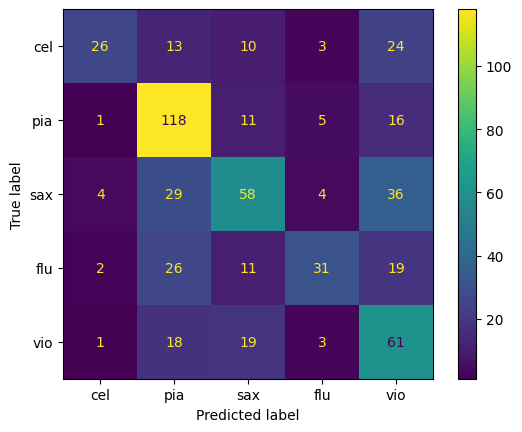

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svm_cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm,display_labels= ["cel", "pia", "sax", "flu", "vio"])
disp.plot()

In [60]:
from dataset_preprocessing import normalize_split_data

x_train_cnn, y_train_cnn, x_val_cnn, y_val_cnn, x_test_cnn, y_test_cnn = normalize_split_data(x_train, y_train, x_test, y_test)
print(x_train_cnn.shape)
print(y_train_cnn.shape)
print(x_val_cnn.shape)
print(y_val_cnn.shape)
print(x_test_cnn.shape)
print(y_test_cnn.shape)


(1755, 128, 259)
(1755,)
(438, 128, 259)
(438,)
(549, 128, 259)
(549,)


In [61]:
from run_cnn import convolutional_model

input_shape = (128, 259, 1)
cnn_model = convolutional_model(input_shape=input_shape)
cnn_model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 128, 259, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 126, 257, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 63, 128, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 126, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 60480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │       604,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,610 (2.33 MB)

 Trainable params: 609,610 (2.33 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [62]:
clf_cnn = cnn_model.fit(x_train_cnn, y_train_cnn, epochs=20, batch_size=32, validation_data=(x_val_cnn, y_val_cnn))

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3242 - loss: 1.5306 - val_accuracy: 0.4087 - val_loss: 1.3766
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4912 - loss: 1.2687 - val_accuracy: 0.5046 - val_loss: 1.2354
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6103 - loss: 1.0668 - val_accuracy: 0.5753 - val_loss: 1.0746
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6826 - loss: 0.8818 - val_accuracy: 0.5571 - val_loss: 1.0636
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7618 - loss: 0.6894 - val_accuracy: 0.6096 - val_loss: 0.9733
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8085 - loss: 0.5688 - val_accuracy: 0.6347 - val_loss: 0.9526
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8792 - loss: 0.4071 - val_accuracy: 0.6073 - val_loss: 1.0387
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9060 - loss: 0.3175 - val_accuracy: 0.5845 - v

In [63]:
from run_cnn import predict_cnn
y_predict_cnn = predict_cnn(cnn_model, x_test_cnn)
print(y_predict_cnn[0])
print(y_test_cnn[0])

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1
1


In [64]:
from sklearn.metrics import f1_score, accuracy_score
print("f1 score for CNN:", format(f1_score(y_test_cnn, y_predict_cnn, average="macro")))
print("accuracy score for CNN:", format(accuracy_score(y_test_cnn, y_predict_cnn)))

f1 score for CNN: 0.6396328018178365
accuracy score for CNN: 0.6520947176684881


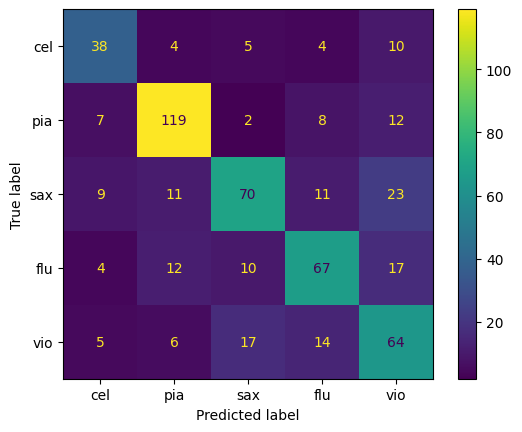

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cnn_cm = confusion_matrix(y_test_cnn, y_predict_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm,display_labels= ["cel", "pia", "sax", "flu", "vio"])
disp.plot()